In [1]:
import numpy as np
from matplotlib import pyplot as plt

EJERCICIO 1

item a

In [2]:
def F(x,y):
  return [x**2+y**2+x*y-7,x**3-y+1]

In [3]:
print(F(1,2))

[0, 0]


luego (1,2) es sol exacta de F(x,y)

item b

In [4]:
def J(x,y):
  return [[2*x+y,2*y+x],[3*x**2,-1]]

In [5]:
print(J(1,2))

[[4, 5], [3, -1]]


In [6]:
np.linalg.inv(J(1,2))

array([[ 0.05263158,  0.26315789],
       [ 0.15789474, -0.21052632]])

item c

In [7]:
def iteracion_de_Newton(p,tol,max_iter):
  normas = []
  iteracion = 0
  while iteracion < max_iter:
    F_eval = np.array(F(p[0],p[1]))
    norma = np.linalg.norm(F_eval)
    normas.append(norma)
    if norma < tol:
      print(f"convergio, sol encontrada en {iteracion} iteraciones")
      return normas
    J_eval = np.array(J(p[0],p[1]))
    delta = np.linalg.solve(J_eval,-F_eval)
    p = p + delta
    iteracion +=1
  else:
    print("se llego al max de iter sin converger")
    return normas



In [8]:
print(iteracion_de_Newton((0.1,0.1),1e-10,50))

convergio, sol encontrada en 15 iteraciones
[np.float64(7.027994095045897), np.float64(10346.151935085643), np.float64(3069.5077541787296), np.float64(936.203253258182), np.float64(275.8210548982248), np.float64(81.48180902371466), np.float64(24.758000683073686), np.float64(8.830184593971968), np.float64(4.3351790143537725), np.float64(13.631482662730734), np.float64(3.166600070371155), np.float64(0.48423901904985167), np.float64(0.019886190400103514), np.float64(3.861255225389724e-05), np.float64(1.4650686465619656e-10), np.float64(2.220446049250313e-16)]


convergio, sol encontrada en 15 iteraciones


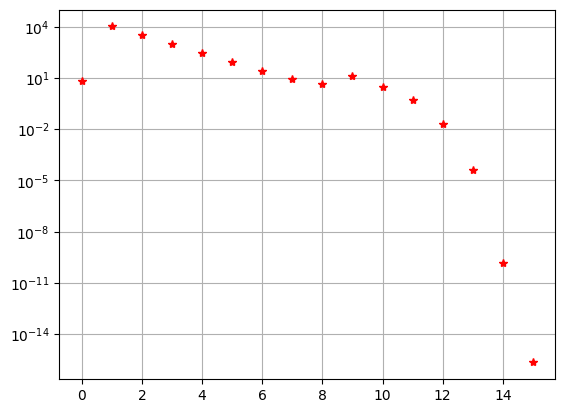

In [9]:
normas_de_convergencia = iteracion_de_Newton((0.1,0.1),1e-10,50)
plt.semilogy(range(len(normas_de_convergencia)),normas_de_convergencia,"r*")
plt.grid(True)
plt.show()

item e

In [10]:
x = np.linspace(-3,3,400)
y = np.linspace(-3,6,400)
X,Y = np.meshgrid(x,y)

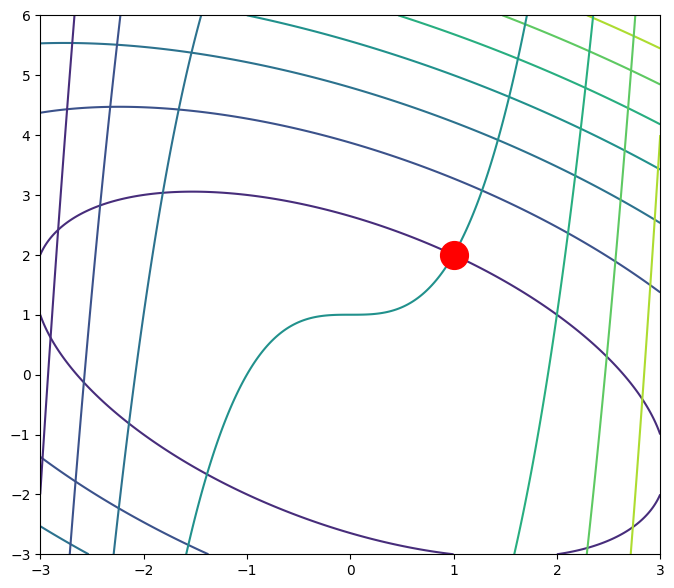

In [11]:
Z1 = X**2+Y**2+X*Y-7
Z2 =X**3-Y+1
plt.figure(figsize=(8,7))
plt.contour(X,Y,Z1)
plt.contour(X,Y,Z2)
plt.plot(1,2,"ro",markersize=20)
plt.xlim([-3,3])
plt.ylim([-3,6])
plt.show()

podemos observar otra solucion del problema en la parte inferior izquierda cercano a (-2.9,-2.2). ejecutemos newton

In [12]:
print(iteracion_de_Newton((-2.9,-2.2),1e-10,50))

convergio, sol encontrada en 6 iteraciones
[np.float64(24.66760266016947), np.float64(6.273667011757747), np.float64(1.2603060142629507), np.float64(0.11060195148834685), np.float64(0.00116039659173628), np.float64(1.3226815077255214e-07), np.float64(1.3322676295501878e-15)]


EJERCICIO 2

item a

In [13]:
import seaborn as sns
import pandas as pd
import numpy as np

# Cargo el dataset original
df_original = sns.load_dataset('titanic')

# Filtro las filas que no tengan valores faltantes en las columnas clave
df = df_original.dropna(subset=['age', 'sex', 'pclass']).copy()


In [14]:
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
885,0,3,female,39.0,0,5,29.1250,Q,Third,woman,False,NaN,Queenstown,no,False
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [15]:
df['sexo_codificado'] = df['sex'].map({'male': 0, 'female': 1})
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,sexo_codificado
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False,0
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,1
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True,1
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,1
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
885,0,3,female,39.0,0,5,29.1250,Q,Third,woman,False,NaN,Queenstown,no,False,1
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True,0
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True,1
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True,0


In [16]:
age_mean = df['age'].mean()
age_std = df['age'].std()
df['age_norma'] = (df['age'] - age_mean) / age_std

pclass_mean = df['pclass'].mean()
pclass_std = df['pclass'].std()
df['pclass_norma'] = (df['pclass'] - pclass_mean) / pclass_std

In [17]:
caracteristicas_X = df[['sexo_codificado', 'pclass_norma', 'age_norma']].values


n = caracteristicas_X.shape[0] #dim
bias_column = np.ones((n, 1))

X = np.hstack((caracteristicas_X, bias_column))

y = df['survived'].values
print(X)

[[ 0.          0.91059403 -0.5300051   1.        ]
 [ 1.         -1.47532941  0.57143041  1.        ]
 [ 1.          0.91059403 -0.25464622  1.        ]
 ...
 [ 1.         -1.47532941 -0.73652426  1.        ]
 [ 0.         -1.47532941 -0.25464622  1.        ]
 [ 0.          0.91059403  0.1583921   1.        ]]


In [18]:
# 1
print(f"Número de muestras (n): {n}")
# 2
fraccion_supervivientes = df['survived'].mean()
print(f"Fracción de supervivientes: {fraccion_supervivientes}")
# 3
print(f"Dimensiones de la matriz X: {X.shape}")

Número de muestras (n): 714
Fracción de supervivientes: 0.4061624649859944
Dimensiones de la matriz X: (714, 4)


item b

In [19]:
def sigma(z):
    return 1 / (1 + np.exp(-z))

def funcion_perdida(w, X, y):
    n = len(y)
    p_hat = sigma(X @ w)
    return (1 / n) * np.sum((p_hat - y) ** 2)

def gradiente_analitica(w, X, y):
    n = len(y)
    p_hat = sigma(X @ w)
    grad = (2 / n) * X.T @ ((p_hat - y) * p_hat * (1 - p_hat))
    return grad

def dif_centradas(w, X, y, epsilon=1e-6):
    grad = np.zeros_like(w)
    for i in range(len(w)):
        w_mas = w.copy()
        w_menos = w.copy()
        w_mas[i] += epsilon
        w_menos[i] -= epsilon
        grad[i] = (funcion_perdida(w_mas, X, y) - funcion_perdida(w_menos, X, y)) / (2 * epsilon)
    return grad

# estoy verificando con un w de prueba aleatorio
np.random.seed(42)
w_prueba = np.random.randn(4)
grad_a = gradiente_analitica(w_prueba, X, y)
grad_n = dif_centradas(w_prueba, X, y)

print("Gradiente Analítico:", grad_a)
print("diferencias centradas :", grad_n)
print("Error absoluto máximo:", np.max(np.abs(grad_a - grad_n)))

Gradiente Analítico: [ 0.00914387  0.05605291 -0.00577127  0.11312153]
diferencias centradas : [ 0.00914387  0.05605291 -0.00577127  0.11312153]
Error absoluto máximo: 2.6065413716303e-11


item c

In [20]:
def descenso_gradiente(X, y, alpha, n_iter):
    w = np.zeros(X.shape[1])
    historial_perdidas = []
    for k in range(n_iter):
        perdidas = funcion_perdida(w, X, y)
        historial_perdidas.append(perdidas)

        grad = gradiente_analitica(w, X, y)

        w = w - alpha * grad

    return w, historial_perdidas

item d

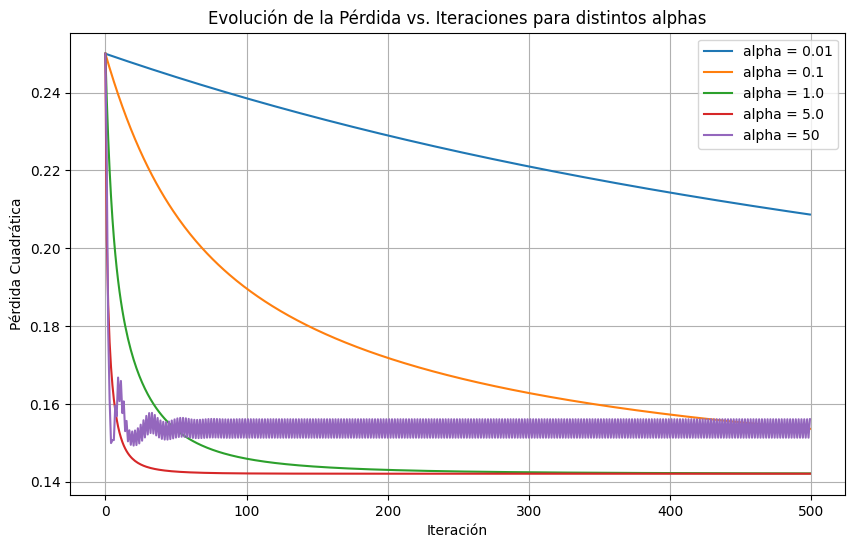

In [23]:


alphas = [0.01, 0.1, 1.0, 5.0, 50]
n_iter = 500

plt.figure(figsize=(10, 6))

mejor_w = None
mejor_alpha = 1.0

for alpha in alphas:
    w_final, history = descenso_gradiente(X, y, alpha, n_iter)
    plt.plot(history, label=f'alpha = {alpha}')


    if alpha == 1.0:
        mejor_w = w_final

plt.title('Evolución de la Pérdida vs. Iteraciones para distintos alphas')
plt.xlabel('Iteración')
plt.ylabel('Pérdida Cuadrática')
plt.legend()
plt.grid(True)
plt.show()

item e

In [24]:
p_hat_final = sigma(X @ mejor_w)
y_pred = (p_hat_final >= 0.5).astype(int)

exactitud_modelo = np.mean(y_pred == y)

clase_mayoritaria = 1 if np.mean(y) > 0.5 else 0
y_pred_trivial = np.full_like(y, fill_value=clase_mayoritaria)

exactitud_trivial = np.mean(y_pred_trivial == y)

print("--- EVALUACIÓN DE DESEMPEÑO ---")
print(f"exactitud del modelo de Regresión Logística: {exactitud_modelo}")
print(f"exactitud de la Clase mayoritaria: {exactitud_trivial}")

--- EVALUACIÓN DE DESEMPEÑO ---
exactitud del modelo de Regresión Logística: 0.7941176470588235
exactitud de la Clase mayoritaria: 0.5938375350140056
